# Plotting NRH radio images of the Sun

Load cleaned Nançay Radioheliograph (NRH) images stored as IDL `.sav` files,
convert them to `sunpy` maps, and produce publication-quality figures and movies.

**Workflow**
1. Load NRH images for one frequency channel on a given day.
2. Optionally load several frequency channels at once.
3. Convert the images to `sunpy` maps.
4. Draw the synthesised beam (bottom-left corner of the map).
5. Plot the NRH map for a chosen frame / timestamp.
6. Download the matching AIA 193 A map (`Fido`).
7. Overplot NRH contours on AIA (single and multiple frequencies).
8. Export an NRH-contour movie for a single frequency over time (MP4).
9. Export an NRH-contour movie for multiple frequencies over time (MP4).

Each `.sav` file holds one frequency channel: `nrh_data` is a `(n_time, ny, nx)`
cube and `nrh_hdr` is a per-frame header record array.


In [24]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob

import numpy as np
import pandas as pd
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, FFMpegWriter

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ImageNormalize, SqrtStretch

import sunpy.map
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames
from sunpy.time import parse_time

from scipy.io import readsav
from tqdm import tqdm

# Reproducibility
seed_val = 7
os.environ['PYTHONHASHSEED'] = str(seed_val)
import random; random.seed(seed_val)
np.random.seed(seed_val)

plt.rcParams['figure.figsize']    = [7, 7]
plt.rcParams['figure.dpi']        = 100
plt.rcParams['savefig.dpi']       = 300
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

## Configuration

Everything you normally change lives in this one cell.


In [25]:
# --- Observation / paths --------------------------------------------------
mydate   = '20251006'                      # day to analyse (YYYYMMDD)
data_dir = f'/home/mnedal/data/NRH/{mydate}'
savedir  = f'{data_dir}/output'            # where figures / movies are written
os.makedirs(savedir, exist_ok=True)

# --- Frame selection ------------------------------------------------------
# NRH cadence here is ~240 frames per second, so frame = 240 * seconds_offset.
FRAME = 240 * 2          # which time index to plot for the single-frame figures

# --- Contour levels (percent of each map's own peak) ----------------------
CONTOUR_LEVELS = np.arange(70, 100, 10) * u.percent

# --- AIA ------------------------------------------------------------------
AIA_CHANNEL = 193        # Angstrom

# --- Movies ---------------------------------------------------------------
MOVIE_FRAME_STEP = 240   # subsample cube for movies (240 -> one frame per second)
MOVIE_FPS        = 5

sav_files = sorted(glob.glob(f'{data_dir}/*.sav'))
print(f'{len(sav_files)} frequency files found:')
print(*sav_files, sep='\n')

10 frequency files found:
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_150_9.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_173_2.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_228_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_270_6.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_298_7.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_327_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_382_2.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_408_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_432_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_444_0.sav


## Helper functions

All the reusable logic sits here so the cells below stay short.


In [26]:
def load_nrh_sav(filename):
    """Read one NRH .sav file into a python dict (keys: nrh_data, nrh_hdr, ...)."""
    return readsav(filename, python_dict=True)


def header_dict(nrh, index):
    """Return the per-frame header at `index` as a plain {NAME: value} dict."""
    names = nrh['nrh_hdr'].dtype.names
    return {name: nrh['nrh_hdr'][name][index] for name in names}


def _to_str(val):
    """Decode bytes coming out of readsav to str; pass through otherwise."""
    return val.decode('utf-8') if isinstance(val, (bytes, bytearray)) else val


def get_beam_params(header, deg_threshold=10.0, verbose=False):
    """Auto-detect the synthesised beam from an NRH header dict.

    The exact field names vary between NRH products, so we scan the header for
    major/minor/position-angle keys instead of assuming BMAJ/BMIN/BPA.

    Returns (bmaj, bmin, bpa) with bmaj/bmin in arcsec and bpa in degrees,
    or None if nothing beam-like is found.
    """
    upper = {k.upper(): k for k in header}

    def pick(*needles):
        for u_key, orig in upper.items():
            if any(n in u_key for n in needles):
                try:
                    return float(header[orig])
                except (TypeError, ValueError):
                    continue
        return None

    bmaj = pick('BMAJ', 'BEAM_MAJ', 'BEAMMAJ', 'MAJOR')
    bmin = pick('BMIN', 'BEAM_MIN', 'BEAMMIN', 'MINOR')
    bpa  = pick('BPA', 'BEAM_PA', 'BEAMPA', 'BEAM_ANGLE', 'PANGLE')

    if verbose:
        beam_like = [k for k in header if any(s in k.upper()
                     for s in ('BEAM', 'BMAJ', 'BMIN', 'BPA', 'MAJOR', 'MINOR'))]
        print(f'  beam-like header keys: {beam_like}')
        print(f'  raw  -> bmaj={bmaj}, bmin={bmin}, bpa={bpa}')

    if bmaj is None or bmin is None:
        return None

    # FITS convention stores BMAJ/BMIN in degrees; NRH .sav products often store
    # arcsec already. Heuristic: a beam < deg_threshold must be in degrees.
    if bmaj < deg_threshold:
        bmaj *= 3600.0
        bmin *= 3600.0
    if bpa is None:
        bpa = 0.0
    return bmaj, bmin, bpa


def build_nrh_map(nrh, index):
    """Construct a sunpy.map.Map for frame `index`, stashing the beam in .meta."""
    b        = header_dict(nrh, index)
    map_data = nrh['nrh_data'][index]

    ref_coord = SkyCoord(0 * u.arcsec, 0 * u.arcsec,
                         frame=frames.Helioprojective(observer='earth',
                                                      obstime=b['DATE_OBS']))
    header = sunpy.map.make_fitswcs_header(
        map_data, ref_coord,
        reference_pixel=[int(b['CRPIX1']) - 1, int(b['CRPIX2']) - 1] * u.pixel,
        scale=[float(b['CDELT1']), float(b['CDELT2'])] * u.arcsec / u.pixel,
        wavelength=float(b['FREQ']) * u.MHz)

    nmap = sunpy.map.Map(map_data, header)
    nmap.meta['bunit_str'] = _to_str(b['BUNIT'])

    beam = get_beam_params(b)
    if beam is not None:
        nmap.meta['bmaj'], nmap.meta['bmin'], nmap.meta['bpa'] = beam
    return nmap


def load_frequency(filename, indices=None):
    """Load one frequency file into a list of sunpy maps.

    indices=None -> every frame; an int -> that single frame (returns one map);
    an iterable -> those frames.
    """
    nrh = load_nrh_sav(filename)
    n   = len(nrh['nrh_data'])
    if indices is None:
        indices = range(n)
    elif np.isscalar(indices):
        return build_nrh_map(nrh, int(indices))
    return [build_nrh_map(nrh, int(i)) for i in indices]


def frame_from_time(nrh, timestamp):
    """Index of the frame whose DATE_OBS is closest to `timestamp`."""
    times = parse_time([t for t in nrh['nrh_hdr']['DATE_OBS']])
    target = parse_time(timestamp)
    return int(np.argmin(np.abs((times - target).to_value('s'))))

In [27]:
def draw_beam(ax, nmap, loc_frac=(0.10, 0.10),
              facecolor='white', edgecolor='black', alpha=0.9):
    """Draw the synthesised beam as an ellipse in the lower-left of the map.

    Beam FWHM (arcsec) is converted to pixels via the map plate scale. The
    position angle follows the FITS convention (from N, through E); matplotlib's
    Ellipse angle is CCW from +x, which matches the map's solar-Y -> +x layout.
    """
    if 'bmaj' not in nmap.meta:
        return None
    bmaj = nmap.meta['bmaj']
    bmin = nmap.meta['bmin']
    bpa  = nmap.meta.get('bpa', 0.0)

    sx = abs(nmap.scale[0].to_value(u.arcsec / u.pix))
    sy = abs(nmap.scale[1].to_value(u.arcsec / u.pix))
    w_px = bmin / sx          # ellipse width  (minor axis along x)
    h_px = bmaj / sy          # ellipse height (major axis along y)

    ny, nx = nmap.data.shape
    pad = 0.5 * max(w_px, h_px)
    cx = loc_frac[0] * nx + pad
    cy = loc_frac[1] * ny + pad

    e = Ellipse((cx, cy), width=w_px, height=h_px, angle=bpa,
                facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, zorder=5)
    ax.add_patch(e)
    return e


def plot_nrh_map(nmap, frame=None, cmap='RdYlBu_r', vmin=None,
                 levels=None, show_beam=True, ax=None):
    """Plot a single NRH map with limb, optional contours and beam marker."""
    if ax is None:
        fig = plt.figure(figsize=[7,7])
        ax = fig.add_subplot(projection=nmap)
    else:
        fig = ax.figure

    img = nmap.plot(axes=ax, cmap=cmap, vmin=vmin)
    if levels is not None:
        with frames.Helioprojective.assume_spherical_screen(nmap.observer_coordinate):
            nmap.draw_contours(axes=ax, levels=levels, autoalign=True, colors='k',
                               linewidths=0.8)
    nmap.draw_limb(color='w')
    if show_beam:
        draw_beam(ax, nmap)
    ax.grid(False)
    if frame is not None:
        ax.text(3, nmap.data.shape[0] - 10, f'frame = {frame}',
                color='white', fontsize=10, alpha=0.6)
    ax.set_title(f"NRH {nmap.meta['wavelnth']} MHz  "
                 f"{nmap.meta['date-obs'].replace('T', ' ')}")
    fig.colorbar(img, ax=ax, pad=0.02, shrink=0.75,
                 label=nmap.meta.get('bunit_str', ''))
    return ax

## 1. Load one frequency channel

Pick a file from `sav_files` (one per frequency) and inspect it.


In [28]:
# Choose which frequency file to work with (0 = lowest frequency listed)
freq_index = 0
filename   = sav_files[freq_index]

nrh = load_nrh_sav(filename)
print('Keys :', list(nrh.keys()))
print('Cube :', nrh['nrh_data'].shape, '(n_time, ny, nx)')
print('Freq :', float(header_dict(nrh, 0)['FREQ']), 'MHz')

# Auto-detect the beam and report what was found (verbose=True prints the keys)
_ = get_beam_params(header_dict(nrh, 0), verbose=True)

Keys : ['nrh_data', 'nrh_hdr']
Cube : (2400, 256, 256) (n_time, ny, nx)
Freq : 150.9 MHz
  beam-like header keys: []
  raw  -> bmaj=None, bmin=None, bpa=None


## 2. Load multiple frequency channels

Build a dict `{frequency_MHz: filename}` for every channel of the day. Loading
the full cube for all channels is memory-heavy, so here we only load the chosen
`FRAME` per channel; load full cubes lazily when a movie needs them.


In [29]:
# Map each frequency (MHz) to its file
freq_files = {}
for f in sav_files:
    hdr = header_dict(load_nrh_sav(f), 0)
    freq_files[round(float(hdr['FREQ']), 1)] = f

print('Available frequencies (MHz):', sorted(freq_files))

# One map per frequency at the chosen FRAME (requirement 3 happens inside)
maps_by_freq = {freq: load_frequency(f, indices=FRAME)
                for freq, f in sorted(freq_files.items())}

for freq, m in maps_by_freq.items():
    has_beam = 'bmaj' in m.meta
    print(f'{freq:6.1f} MHz  ->  Rsun = {m.rsun_obs:.1f}, beam detected: {has_beam}')

Available frequencies (MHz): [150.9, 173.2, 228.0, 270.6, 298.7, 327.0, 382.2, 408.0, 432.0, 444.0]
 150.9 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 173.2 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 228.0 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 270.6 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 298.7 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 327.0 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 382.2 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 408.0 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 432.0 MHz  ->  Rsun = 959.5 arcsec, beam detected: False
 444.0 MHz  ->  Rsun = 959.5 arcsec, beam detected: False


## 3. Convert images to sunpy maps

Done by `build_nrh_map` / `load_frequency` above. `maps_by_freq` already holds
one `sunpy.map.Map` per frequency for the chosen frame.


## 4 & 5. Plot an NRH map for a given frame, with the beam

`plot_nrh_map` shows the map, the limb, optional contours and the synthesised
beam ellipse in the lower-left corner.


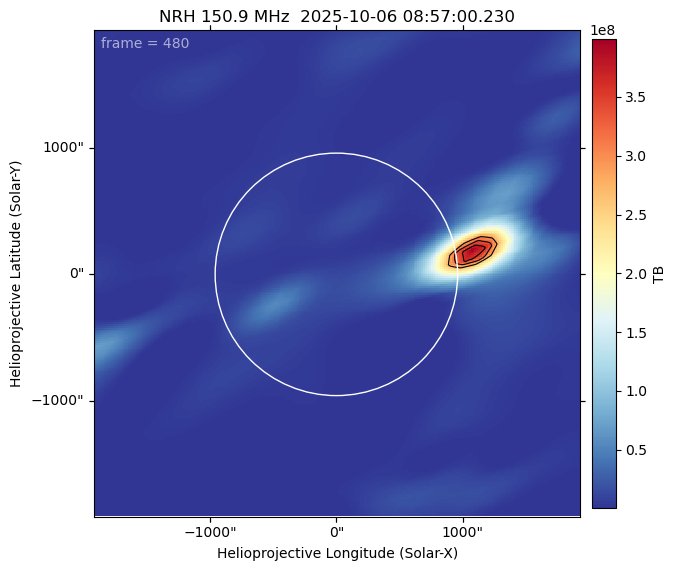

In [30]:
nrh_map = maps_by_freq[sorted(freq_files)[freq_index]]

plot_nrh_map(nrh_map, frame=FRAME, vmin=0.5e6, levels=CONTOUR_LEVELS)
plt.tight_layout()
plt.show()

Closest frame to 2025-10-06T08:58:30: index 839 (b'2025-10-06T08:58:29.980Z')


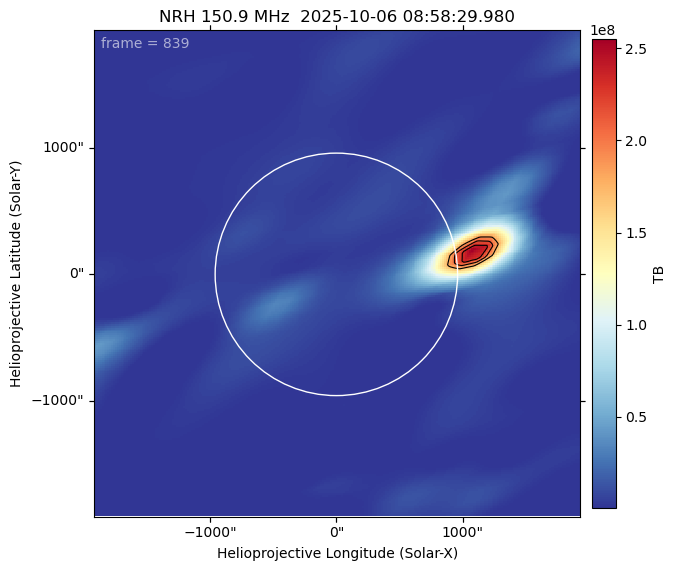

In [31]:
# Selecting a frame by timestamp instead of index
ts = '2025-10-06T08:58:30'
idx = frame_from_time(nrh, ts)
print(f'Closest frame to {ts}: index {idx} '
      f"({header_dict(nrh, idx)['DATE_OBS']})")

plot_nrh_map(build_nrh_map(nrh, idx), frame=idx, vmin=0.5e6, levels=CONTOUR_LEVELS)
plt.tight_layout()
plt.show()

## 6. Download and plot the matching AIA 193 map

Fetch the AIA image closest to the NRH timestamp with `Fido`. Needs internet at
run time; files are cached under `savedir/aia`.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.193A_2025_10_06T08_57_04.84Z.image_lev1.fits:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

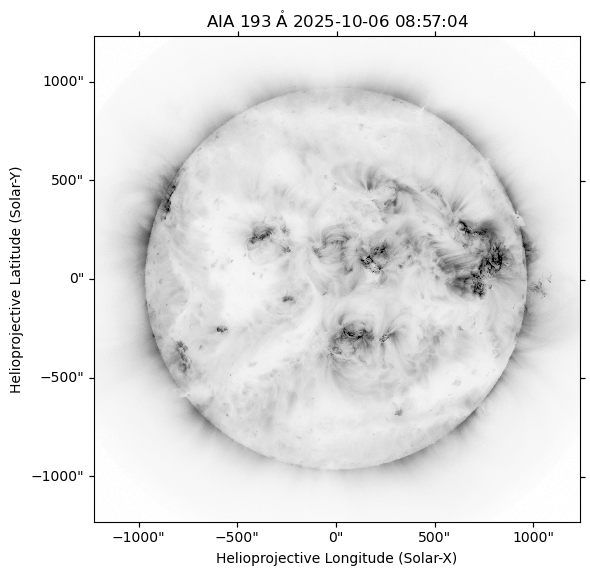

In [33]:
def download_aia(timestamp, channel=193, window=6*u.s, out_dir=None):
    """Download the AIA map closest to `timestamp` and return it as a sunpy Map."""
    out_dir = out_dir or os.path.join(savedir, 'aia')
    os.makedirs(out_dir, exist_ok=True)
    t = parse_time(timestamp)

    query = Fido.search(a.Time(t - window, t + window),
                        a.Instrument.aia,
                        a.Wavelength(channel * u.angstrom))
    if query.file_num == 0:
        raise RuntimeError(f'No AIA {channel} A files near {timestamp}')

    files = Fido.fetch(query[0,0], site='nso', path=os.path.join(out_dir, '{file}'))
    return sunpy.map.Map(files[0])


aia_map = download_aia(nrh_map.meta['date-obs'], channel=AIA_CHANNEL)

fig = plt.figure(figsize=[6,6])
ax = fig.add_subplot(projection=aia_map)
aia_map.plot_settings['norm'] = ImageNormalize(vmin=0, vmax=4e3,
                                               stretch=SqrtStretch())
aia_map.plot(axes=ax, cmap='Greys')
ax.grid(False)
fig.tight_layout()
plt.show()

## 7. Overplot NRH contours on AIA

Reproject the NRH map onto the AIA WCS (assuming a spherical screen so the
above-the-limb radio source projects sensibly), then draw contours.


2026-06-26 13:22:38 - reproject.common - INFO: Calling _reproject_full in non-dask mode


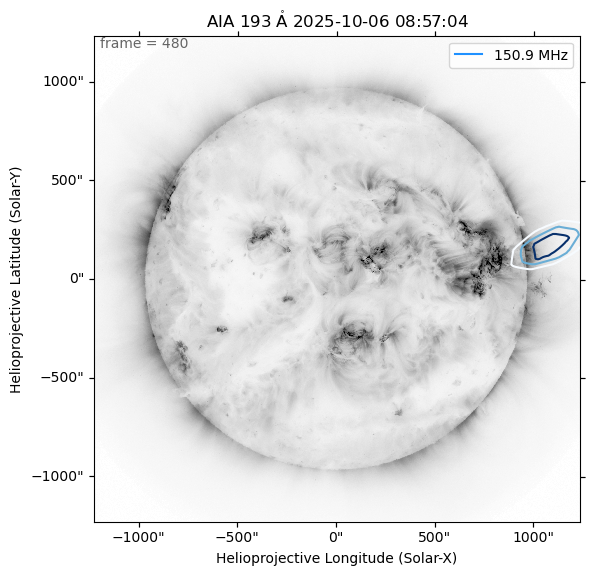

In [34]:
def reproject_to_aia(nmap, aia_map):
    """Reproject an NRH map onto the AIA WCS (spherical-screen assumption)."""
    with frames.Helioprojective.assume_spherical_screen(aia_map.observer_coordinate):
        return nmap.reproject_to(aia_map.wcs)


nrh_on_aia = reproject_to_aia(nrh_map, aia_map)

fig = plt.figure(figsize=[6,6])
ax = fig.add_subplot(projection=aia_map)
aia_map.plot(axes=ax, cmap='Greys')
nrh_on_aia.draw_contours(axes=ax, levels=CONTOUR_LEVELS, cmap='Blues')
ax.text(50, aia_map.data.shape[0] - 100, f'frame = {FRAME}',
        color='black', fontsize=10, alpha=0.6)
handle = mlines.Line2D([], [], color='dodgerblue',
                       label=f"{nrh_map.meta['wavelnth']} MHz")
ax.legend(handles=[handle])
ax.grid(False)
fig.tight_layout()
plt.show()

### 7b. Contours of several frequencies on one AIA map

One colour per frequency, lowest -> highest.


Overplotting frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:15<00:00, 49.58s/it]


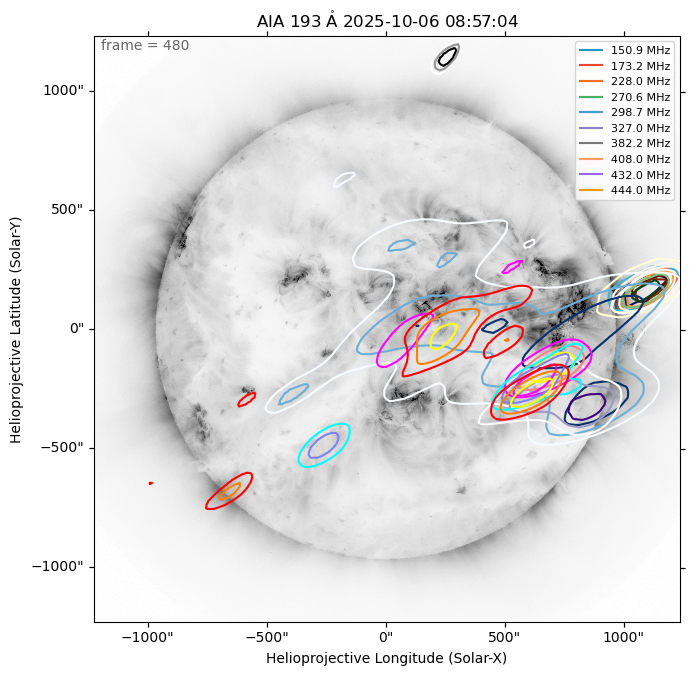

In [35]:
import matplotlib.cm as cm

freqs = sorted(maps_by_freq)
cmaps = ['YlGnBu', 'Reds', 'Oranges', 'Greens', 'Blues', 'Purples', 'Greys',
         'spring', 'cool', 'autumn']
line_colors = {cmap: cm.get_cmap(cmap)(0.6) for cmap in cmaps}

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(projection=aia_map)
aia_map.plot(axes=ax, cmap='Greys')
ax.text(50, aia_map.data.shape[0] - 100, f'frame = {FRAME}',
        color='black', fontsize=10, alpha=0.6)

handles = []
for i, freq in enumerate(tqdm(freqs, desc='Overplotting frequencies')):
    cmap_name = cmaps[i % len(cmaps)]
    nrh_i = reproject_to_aia(maps_by_freq[freq], aia_map)
    nrh_i.draw_contours(axes=ax, levels=CONTOUR_LEVELS, cmap=cmap_name)
    handles.append(mlines.Line2D([], [], color=line_colors[cmap_name],
                                 label=f'{freq} MHz'))

ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.grid(False)
fig.tight_layout()
plt.show()

## 8. Movie of NRH contours over time — single frequency (MP4)

Animate the NRH contours of one frequency over time on a fixed AIA background.
The cube is subsampled by `MOVIE_FRAME_STEP`. Requires `ffmpeg` on the system.


2026-06-26 13:34:37 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-06-26 13:34:37 - matplotlib.animation - INFO: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -r 5 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mnedal/data/NRH/20251006/output/nrh_150MHz_contours.mp4


ValueError: The passed figure is not managed by pyplot

2026-06-26 13:34:39 - reproject.common - INFO: Calling _reproject_full in non-dask mode


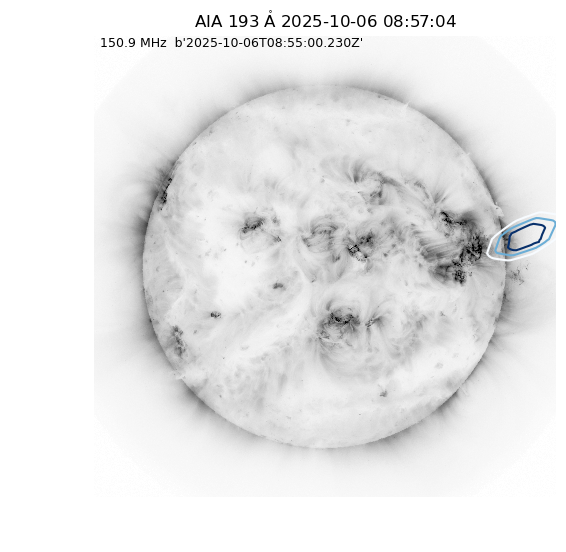

In [36]:
def make_single_freq_movie(filename, aia_map, out_path,
                            frame_step=MOVIE_FRAME_STEP, levels=CONTOUR_LEVELS,
                            fps=MOVIE_FPS, contour_cmap='Blues'):
    """Write an MP4 of one frequency's NRH contours over time on AIA."""
    nrh = load_nrh_sav(filename)
    n_total = len(nrh['nrh_data'])
    indices = list(range(0, n_total, frame_step))
    freq = round(float(header_dict(nrh, 0)['FREQ']), 1)

    fig = plt.figure(figsize=[6, 6])
    ax = fig.add_subplot(projection=aia_map)

    def update(idx):
        ax.clear()
        aia_map.plot(axes=ax, cmap='Greys')
        nrh_i = reproject_to_aia(build_nrh_map(nrh, idx), aia_map)
        nrh_i.draw_contours(axes=ax, levels=levels, cmap=contour_cmap)
        ax.text(50, aia_map.data.shape[0] - 100,
                f"{freq} MHz  {header_dict(nrh, idx)['DATE_OBS']}",
                color='black', fontsize=9)
        ax.grid(False)
        return ax,

    anim = FuncAnimation(fig, update, frames=indices, blit=False)
    anim.save(out_path, writer=FFMpegWriter(fps=fps), dpi=100)
    plt.close(fig)
    print(f'Saved {out_path}  ({len(indices)} frames)')
    return out_path


single_movie = os.path.join(savedir, f'nrh_{int(nrh_map.meta["wavelnth"])}MHz_contours.mp4')
make_single_freq_movie(filename, aia_map, single_movie)

## 9. Movie of NRH contours over time — multiple frequencies (MP4)

At each time step, overplot every frequency's contours (one colour each) on the
AIA background. Assumes the channels share the same time sampling.


2026-06-26 13:37:08 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-06-26 13:37:08 - matplotlib.animation - INFO: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 700x700 -pix_fmt rgba -r 5 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mnedal/data/NRH/20251006/output/nrh_multifreq_contours.mp4


ValueError: The passed figure is not managed by pyplot

2026-06-26 13:37:09 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:37:59 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:38:48 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:39:38 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:40:28 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:41:17 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:42:07 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:42:57 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:43:46 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 13:44:36 - reproject.common - INFO: Calling _reproject_full in non-dask mode


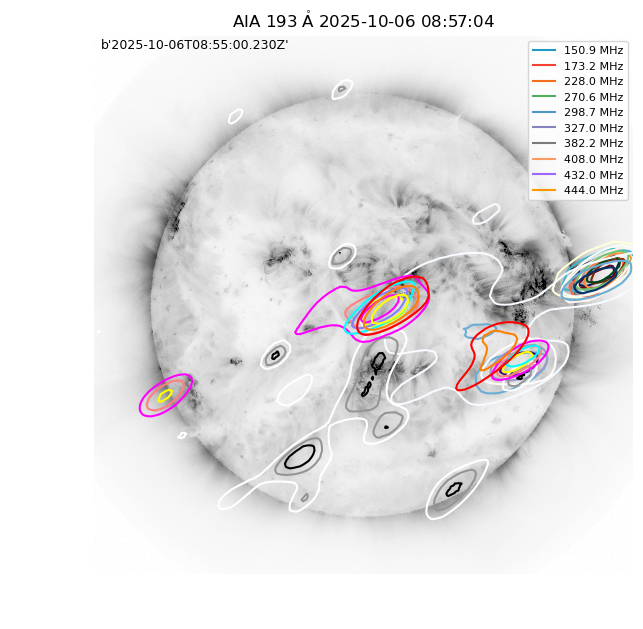

In [37]:
def make_multi_freq_movie(freq_files, aia_map, out_path,
                           frame_step=MOVIE_FRAME_STEP, levels=CONTOUR_LEVELS,
                           fps=MOVIE_FPS):
    """Write an MP4 of all frequencies' NRH contours over time on AIA."""
    freqs = sorted(freq_files)
    nrhs  = {freq: load_nrh_sav(freq_files[freq]) for freq in freqs}
    n_min = min(len(n['nrh_data']) for n in nrhs.values())
    indices = list(range(0, n_min, frame_step))

    fig = plt.figure(figsize=[7, 7])
    ax = fig.add_subplot(projection=aia_map)

    def update(idx):
        ax.clear()
        aia_map.plot(axes=ax, cmap='Greys')
        handles = []
        for i, freq in enumerate(freqs):
            cmap_name = cmaps[i % len(cmaps)]
            nrh_i = reproject_to_aia(build_nrh_map(nrhs[freq], idx), aia_map)
            nrh_i.draw_contours(axes=ax, levels=levels, cmap=cmap_name)
            handles.append(mlines.Line2D([], [], color=line_colors[cmap_name],
                                         label=f'{freq} MHz'))
        ax.text(50, aia_map.data.shape[0] - 100,
                header_dict(nrhs[freqs[0]], idx)['DATE_OBS'],
                color='black', fontsize=9)
        ax.legend(handles=handles, loc='upper right', fontsize=8)
        ax.grid(False)
        return ax,

    anim = FuncAnimation(fig, update, frames=indices, blit=False)
    anim.save(out_path, writer=FFMpegWriter(fps=fps), dpi=100)
    plt.close(fig)
    print(f'Saved {out_path}  ({len(indices)} frames)')
    return out_path


multi_movie = os.path.join(savedir, 'nrh_multifreq_contours.mp4')
make_multi_freq_movie(freq_files, aia_map, multi_movie)